In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.pipeline import Pipeline
import warnings
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
warnings.filterwarnings('ignore')

In [9]:
modeling_data = pd.read_csv('../data/final_youtube_v2.csv')
modeling_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17528 entries, 0 to 17527
Data columns (total 49 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                17528 non-null  int64  
 1   views                     17528 non-null  int64  
 2   likes                     17528 non-null  int64  
 3   comments                  17528 non-null  int64  
 4   views_log                 17528 non-null  float64
 5   likes_log                 17528 non-null  float64
 6   comments_log              17528 non-null  float64
 7   likes_log_win             17528 non-null  float64
 8   comments_log_win          17528 non-null  float64
 9   duration_scaled           17528 non-null  float64
 10  framerate_scaled          17528 non-null  float64
 11  bitrate_scaled            17528 non-null  float64
 12  views_log_scaled          17528 non-null  float64
 13  likes_log_scaled          17528 non-null  float64
 14  commen

In [10]:
cat_columns = [col for col in modeling_data.columns if col.startswith('cat_')]

for col in cat_columns:
    modeling_data[col] = modeling_data[col].astype(int)

print(f"✅ Converted {len(cat_columns)} category columns to int")

print(f"\nData types:")
print(modeling_data[cat_columns].dtypes.value_counts())

✅ Converted 15 category columns to int

Data types:
int64    15
Name: count, dtype: int64


In [18]:
modeling_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17528 entries, 0 to 17527
Data columns (total 49 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                17528 non-null  int64  
 1   views                     17528 non-null  int64  
 2   likes                     17528 non-null  int64  
 3   comments                  17528 non-null  int64  
 4   views_log                 17528 non-null  float64
 5   likes_log                 17528 non-null  float64
 6   comments_log              17528 non-null  float64
 7   likes_log_win             17528 non-null  float64
 8   comments_log_win          17528 non-null  float64
 9   duration_scaled           17528 non-null  float64
 10  framerate_scaled          17528 non-null  float64
 11  bitrate_scaled            17528 non-null  float64
 12  views_log_scaled          17528 non-null  float64
 13  likes_log_scaled          17528 non-null  float64
 14  commen

# Loại bỏ các cột có thể dẫn đến data leakage

In [19]:
leakage_features = [
    # Engagement metrics (phụ thuộc views)
    'views', 'comments'
    'likes_log_win',

    # Scaled versions của engagement
    'likes_log_scaled',
    'likes_log_win_scaled',

    # Other
    'Unnamed: 0',

]

# Loại bỏ các cột tồn tại
existing_leakage = [col for col in leakage_features if col in modeling_data.columns]
df_clean = modeling_data.drop(columns=existing_leakage, errors='ignore')

print(f"Removed {len(existing_leakage)} leakage features")
print(f"Remaining: {df_clean.shape[1]} columns")

Removed 4 leakage features
Remaining: 45 columns


In [20]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17528 entries, 0 to 17527
Data columns (total 45 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   likes                     17528 non-null  int64  
 1   comments                  17528 non-null  int64  
 2   views_log                 17528 non-null  float64
 3   likes_log                 17528 non-null  float64
 4   comments_log              17528 non-null  float64
 5   likes_log_win             17528 non-null  float64
 6   comments_log_win          17528 non-null  float64
 7   duration_scaled           17528 non-null  float64
 8   framerate_scaled          17528 non-null  float64
 9   bitrate_scaled            17528 non-null  float64
 10  views_log_scaled          17528 non-null  float64
 11  comments_log_scaled       17528 non-null  float64
 12  comments_log_win_scaled   17528 non-null  float64
 13  has_description           17528 non-null  int64  
 14  has_ha

# Chuẩn bị data cho huấn luyện

In [21]:
# Target
y = df_clean['likes_log']

# Features
X = df_clean.drop(columns=['likes_log', 'likes'])

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

# Split train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train set: {X_train.shape}")
print(f"Test set:  {X_test.shape}")
print(f"Split ratio: 80/20")

X shape: (17528, 43)
y shape: (17528,)
Train set: (14022, 43)
Test set:  (3506, 43)
Split ratio: 80/20


# Tạo pipeline huấn luyện

In [39]:
pipeline = Pipeline([
    ("poly", PolynomialFeatures(
        degree=1,
        interaction_only=True,
        include_bias=False
    )),
    ("linear", LinearRegression())
])

# Fit
pipeline.fit(X_train, y_train)

# Predict
y_pred = pipeline.predict(X_test)


In [40]:
y_train_pred_log = pipeline.predict(X_train)
y_test_pred_log = pipeline.predict(X_test)

y_train_orig = np.expm1(y_train)
y_test_orig = np.expm1(y_test)
y_train_pred_orig = np.expm1(y_train_pred_log)
y_test_pred_orig = np.expm1(y_test_pred_log)

# Đánh giá trên tập kiểm thử và huấn luyện

In [41]:
r2_train_log = r2_score(y_train, y_train_pred_log)
r2_test_log = r2_score(y_test, y_test_pred_log)
mse_train_log = mean_squared_error(y_train, y_train_pred_log)
mse_test_log = mean_squared_error(y_test, y_test_pred_log)
mae_train_log = mean_absolute_error(y_train, y_train_pred_log)
mae_test_log = mean_absolute_error(y_test, y_test_pred_log)

print(f"{'Metric':<20s} {'Train':>15s} {'Test':>15s}")
print("-" * 60)
print(f"{'R² Score':<20s} {r2_train_log:>15.4f} {r2_test_log:>15.4f}")
print(f"{'MSE':<20s} {mse_train_log:>15.4f} {mse_test_log:>15.4f}")
print(f"{'RMSE':<20s} {np.sqrt(mse_train_log):>15.4f} {np.sqrt(mse_test_log):>15.4f}")
print(f"{'MAE':<20s} {mae_train_log:>15.4f} {mae_test_log:>15.4f}")

overfit = r2_train_log - r2_test_log
print(f"\n{'Overfit (R² diff)':<20s} {overfit:>15.4f}")

if overfit > 0.1:
    print(f"   ⚠️ Model có dấu hiệu overfit")
elif overfit < -0.1:
    print(f"   ⚠️ Model có dấu hiệu underfit")
else:
    print(f"   ✅ Model generalize tốt")

Metric                         Train            Test
------------------------------------------------------------
R² Score                      0.9695          0.9654
MSE                           0.0748          0.0886
RMSE                          0.2734          0.2977
MAE                           0.1123          0.1151

Overfit (R² diff)             0.0040
   ✅ Model generalize tốt


# Plot đánh giá

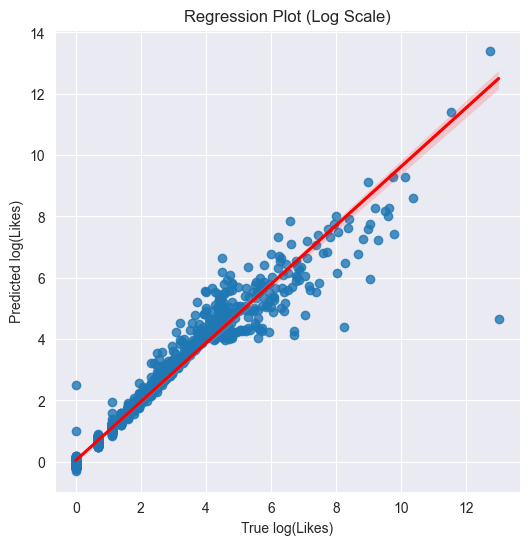

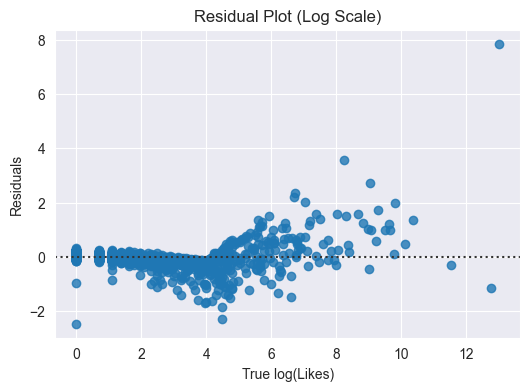

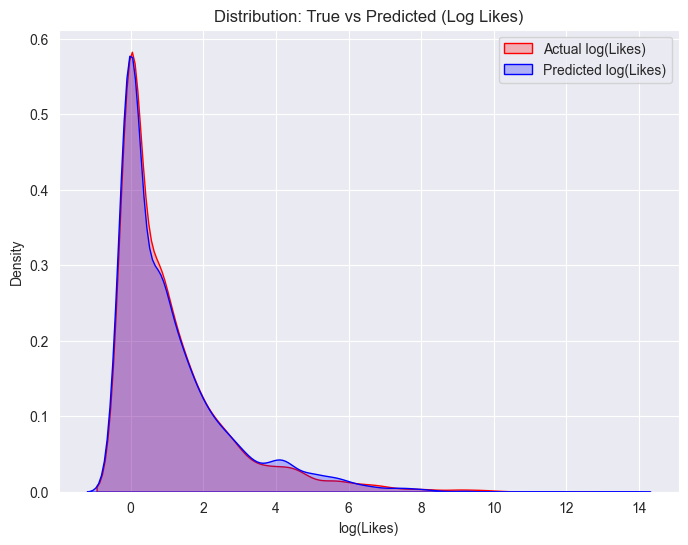

In [42]:
y_true = y_test
y_pred = y_pred
residuals = y_true - y_pred

# ----- Regression plot (log scale) -----
plt.figure(figsize=(6,6))
sns.regplot(x=y_true, y=y_pred, line_kws={'color':'red'})
plt.xlabel("True log(Likes)")
plt.ylabel("Predicted log(Likes)")
plt.title("Regression Plot (Log Scale)")
plt.show()

# ----- Residual plot (log scale) -----
plt.figure(figsize=(6,4))
sns.residplot(x=y_true, y=residuals, line_kws={'color':'red'})
plt.xlabel("True log(Likes)")
plt.ylabel("Residuals")
plt.title("Residual Plot (Log Scale)")
plt.show()

# ----- Distribution comparison -----
plt.figure(figsize=(8,6))
sns.kdeplot(y_true, color='red', label='Actual log(Likes)', shade=True)
sns.kdeplot(y_pred, color='blue', label='Predicted log(Likes)', shade=True)
plt.title('Distribution: True vs Predicted (Log Likes)')
plt.xlabel('log(Likes)')
plt.ylabel('Density')
plt.legend()
plt.show()

# K-Fold CrossValidation

In [43]:
k = 5
kf = KFold(n_splits=5, shuffle=True, random_state=0)
mse_scores = cross_val_score(pipeline, X, y, cv=kf, scoring='neg_mean_squared_error')
rmse_scores = cross_val_score(pipeline, X, y, cv=kf, scoring='neg_root_mean_squared_error')
mae_scores = cross_val_score(pipeline, X, y, cv=kf, scoring='neg_mean_absolute_error')
r2_scores = cross_val_score(pipeline, X, y, cv=kf, scoring='r2')

In [44]:
mse_scores = pd.DataFrame(mse_scores*-1, columns=['MSE'])
rmse_scores = pd.DataFrame(rmse_scores*-1, columns=['RMSE'])
mae_scores = pd.DataFrame(mae_scores*-1, columns=['MAE'])
r2_scores = pd.DataFrame(r2_scores, columns=['R2'])
score = pd.concat([mse_scores, rmse_scores, mae_scores, r2_scores], axis=1)
score

,MSE,RMSE,MAE,R2
0,0.071841,0.268031,0.115393,0.971189
1,0.063834,0.252654,0.112240,0.973424
2,0.099866,0.316016,0.109852,0.961154
3,0.080737,0.284142,0.120874,0.968460
4,0.073503,0.271113,0.113465,0.968370


In [45]:
print(f"Average MSE across {k} folds: {np.mean(mse_scores):.2f}")
print(f"Average RMSE across {k} folds: {np.mean(rmse_scores):.2f}")
print(f"Average MAE across {k} folds: {np.mean(mae_scores):.2f}")
print(f"Average R2 across {k} folds: {np.mean(r2_scores):.2f}")

Average MSE across 5 folds: 0.08
Average RMSE across 5 folds: 0.28
Average MAE across 5 folds: 0.11
Average R2 across 5 folds: 0.97


# Thực nghiệm với poly_degree = 2

In [46]:
pipeline2 = Pipeline([
    ("poly", PolynomialFeatures(
        degree=2,
        interaction_only=True,
        include_bias=False
    )),
    ("linear", LinearRegression())
])

# Fit
pipeline2.fit(X_train, y_train)

# Predict
y_pred = pipeline2.predict(X_test)


In [47]:
y_train_pred_log = pipeline2.predict(X_train)
y_test_pred_log = pipeline2.predict(X_test)

y_train_orig = np.expm1(y_train)
y_test_orig = np.expm1(y_test)
y_train_pred_orig = np.expm1(y_train_pred_log)
y_test_pred_orig = np.expm1(y_test_pred_log)

In [48]:
r2_train_log = r2_score(y_train, y_train_pred_log)
r2_test_log = r2_score(y_test, y_test_pred_log)
mse_train_log = mean_squared_error(y_train, y_train_pred_log)
mse_test_log = mean_squared_error(y_test, y_test_pred_log)
mae_train_log = mean_absolute_error(y_train, y_train_pred_log)
mae_test_log = mean_absolute_error(y_test, y_test_pred_log)

print(f"{'Metric':<20s} {'Train':>15s} {'Test':>15s}")
print("-" * 60)
print(f"{'R² Score':<20s} {r2_train_log:>15.4f} {r2_test_log:>15.4f}")
print(f"{'MSE':<20s} {mse_train_log:>15.4f} {mse_test_log:>15.4f}")
print(f"{'RMSE':<20s} {np.sqrt(mse_train_log):>15.4f} {np.sqrt(mse_test_log):>15.4f}")
print(f"{'MAE':<20s} {mae_train_log:>15.4f} {mae_test_log:>15.4f}")

overfit = r2_train_log - r2_test_log
print(f"\n{'Overfit (R² diff)':<20s} {overfit:>15.4f}")

if overfit > 0.1:
    print(f"   ⚠️ Model có dấu hiệu overfit")
elif overfit < -0.1:
    print(f"   ⚠️ Model có dấu hiệu underfit")
else:
    print(f"   ✅ Model generalize tốt")

Metric                         Train            Test
------------------------------------------------------------
R² Score                      0.9860          0.8172
MSE                           0.0343          0.4682
RMSE                          0.1851          0.6843
MAE                           0.0845          0.1051

Overfit (R² diff)             0.1688
   ⚠️ Model có dấu hiệu overfit


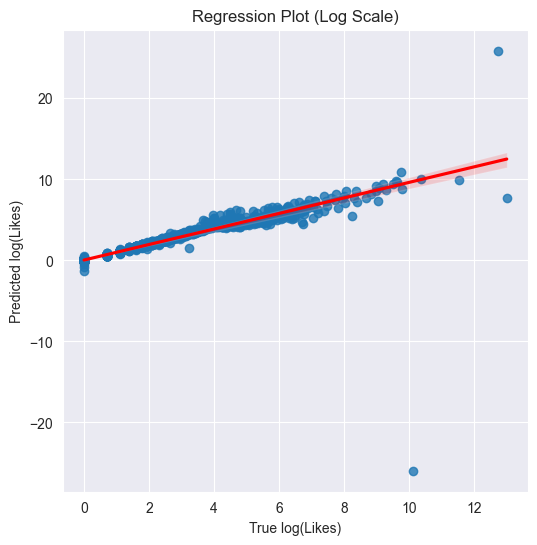

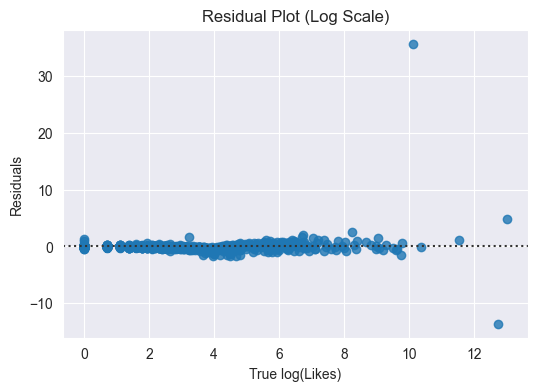

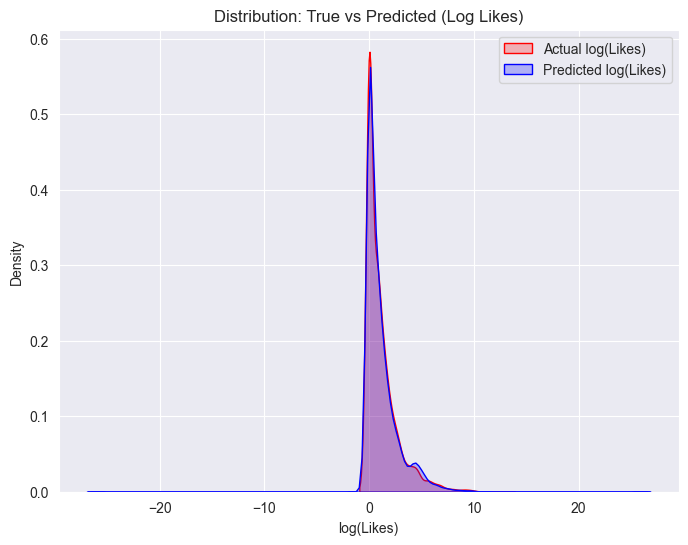

In [49]:
y_true = y_test
y_pred = y_pred
residuals = y_true - y_pred

# ----- Regression plot (log scale) -----
plt.figure(figsize=(6,6))
sns.regplot(x=y_true, y=y_pred, line_kws={'color':'red'})
plt.xlabel("True log(Likes)")
plt.ylabel("Predicted log(Likes)")
plt.title("Regression Plot (Log Scale)")
plt.show()

# ----- Residual plot (log scale) -----
plt.figure(figsize=(6,4))
sns.residplot(x=y_true, y=residuals, line_kws={'color':'red'})
plt.xlabel("True log(Likes)")
plt.ylabel("Residuals")
plt.title("Residual Plot (Log Scale)")
plt.show()

# ----- Distribution comparison -----
plt.figure(figsize=(8,6))
sns.kdeplot(y_true, color='red', label='Actual log(Likes)', shade=True)
sns.kdeplot(y_pred, color='blue', label='Predicted log(Likes)', shade=True)
plt.title('Distribution: True vs Predicted (Log Likes)')
plt.xlabel('log(Likes)')
plt.ylabel('Density')
plt.legend()
plt.show()

In [50]:
k = 5
kf = KFold(n_splits=5, shuffle=True, random_state=0)
mse_scores = cross_val_score(pipeline2, X, y, cv=kf, scoring='neg_mean_squared_error')
rmse_scores = cross_val_score(pipeline2, X, y, cv=kf, scoring='neg_root_mean_squared_error')
mae_scores = cross_val_score(pipeline2, X, y, cv=kf, scoring='neg_mean_absolute_error')
r2_scores = cross_val_score(pipeline2, X, y, cv=kf, scoring='r2')

In [51]:
mse_scores = pd.DataFrame(mse_scores*-1, columns=['MSE'])
rmse_scores = pd.DataFrame(rmse_scores*-1, columns=['RMSE'])
mae_scores = pd.DataFrame(mae_scores*-1, columns=['MAE'])
r2_scores = pd.DataFrame(r2_scores, columns=['R2'])
score = pd.concat([mse_scores, rmse_scores, mae_scores, r2_scores], axis=1)
score

,MSE,RMSE,MAE,R2
0,0.071117,0.266678,0.096684,0.971479
1,0.087197,0.295291,0.099504,0.963698
2,0.355483,0.596224,0.105212,0.861723
3,0.061021,0.247024,0.099469,0.976162
4,0.231128,0.480758,0.101939,0.900541


In [52]:
print(f"Average MSE across {k} folds: {np.mean(mse_scores):.2f}")
print(f"Average RMSE across {k} folds: {np.mean(rmse_scores):.2f}")
print(f"Average MAE across {k} folds: {np.mean(mae_scores):.2f}")
print(f"Average R2 across {k} folds: {np.mean(r2_scores):.2f}")

Average MSE across 5 folds: 0.16
Average RMSE across 5 folds: 0.38
Average MAE across 5 folds: 0.10
Average R2 across 5 folds: 0.93
